[2.         0.45454545]
[-0.  1.]


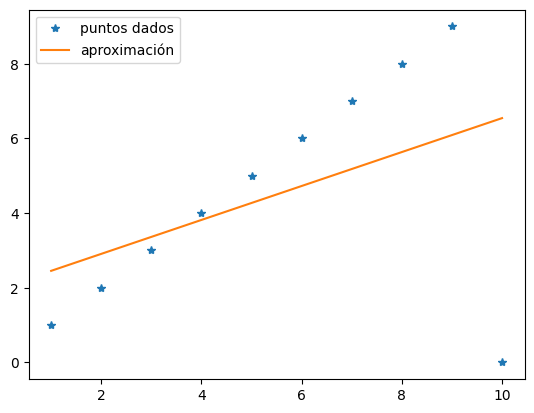

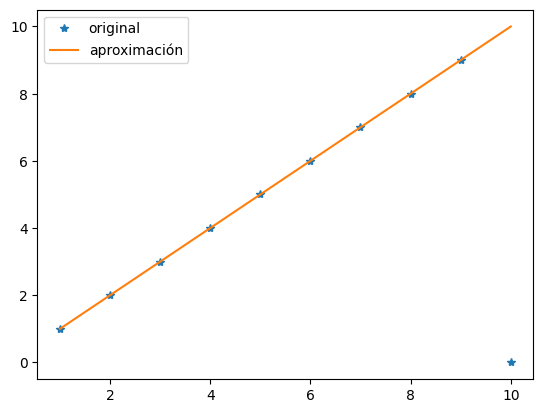

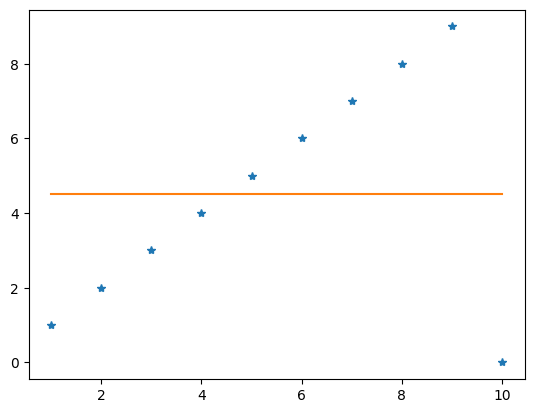

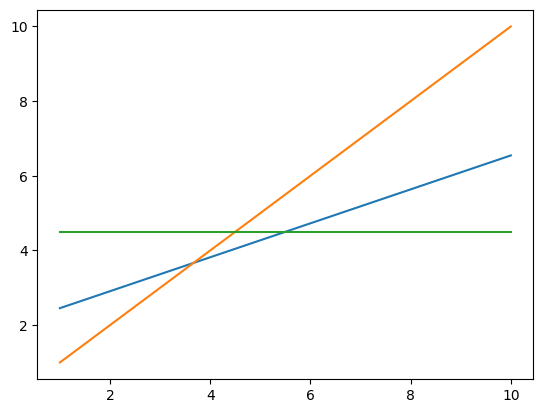

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

#FUNCIONES A USAR

import numpy as np

#Funciones a usar

def sol_trsupcol(A, b):
    n = len(b)
    x = b.copy()

    for idx in reversed(range(n)):
        if b[idx] != 0:
            j = idx
            break

    for i in reversed(range(j + 1)):
        x[i] = x[i] / A[i, i]
        x[:i] = x[:i] - A[:i, i] * x[i]

    return x


def givens(x1,x2):
    c = 1.
    s = 0.
    ax1 = abs(x1)
    ax2 = abs(x2)
    if ax1 + ax2 > 0:
        if ax2 > ax1:
            tau = -x1/x2
            s = -np.sign(x2)/np.sqrt(1 + tau**2)
            c = tau*s
        else:
            tau = -x2/x1
            c = np.sign(x1)/np.sqrt(1 + tau**2)
            s = tau*c
    return c, s


def qrgivensp(A):
    m, n = A.shape
    Q = np.eye(m)
    P = np.eye(n)
    R = A.copy()
    # Forma rápida de calcular la norma de todas las columnas de A
    c_norm = np.linalg.norm(A, axis=0) ** 2
    p = min(m - 1, n)

    for j in range(p):
        # Pivoteo por derecha, cambiando columnas en vez de filas
        ind_pivot = j + np.argmax(c_norm[j:])
        if ind_pivot != j:
            R[:, [ind_pivot, j]] = R[:, [j, ind_pivot]]
            P[:, [ind_pivot, j]] = P[:, [j, ind_pivot]]
            c_norm[[ind_pivot, j]] = c_norm[[j, ind_pivot]]
        # Givens común y corriente
        for i in range(j+1, m):
            if R[i, j] != 0:
                #I = [j, i], J = j:
                c, s = givens(R[j, j], R[i, j])
                G = np.array([[c, -s], [s, c]])

                R[[j, i], j:] = G @ R[[j, i], j:]
                Q[:, [j, i]] = Q[:, [j, i]] @ G.T
        # Actualización de c_norm SOLO UNA VEZ DESPUES DE ACTUALIZAR FILAS
        c_norm[j:] = c_norm[j:] - R[j, j:] * R[j, j:]

    if m <= n and R[m - 1, m - 1] < 0:
        # J = m:
        R[m - 1, m - 1:] = -R[m - 1, m - 1:]
        Q[:, m - 1] = -Q[:, m - 1]

    return Q, R, P


def sol_cuadmin(A, b):
    m, n = A.shape
    Q, R, P = qrgivensp(A)

    y = np.zeros(n)
    q = Q.T @ b
    r = np.diag(R)
    p = min(m,n)
    busqueda_ceros = np.where(r == 0)[0]
    if len(busqueda_ceros) != 0:
        p = busqueda_ceros[0]

    y[:p] = sol_trsupcol(R[:p, :p], q[:p])

    x = P@y

    return  x, np.linalg.norm(q[p:])

############################################################################
#EJERCICIO 10

A=np.zeros((10, 2))

for i in range(10):
    A[i, 0]=1
    A[i, 1]=i+1

b = np.array([1., 2, 3, 4, 5, 6, 7, 8, 9, 0])

#Minimos cuadrados
z_2, z_min = sol_cuadmin(A, b)
z_aprox = A@z_2
print(z_2)

#Norma 1
I = np.eye(10)
A_bu = np.block([[A, -I], [-A, -I]])
b_bu = np.block([b, -b])
c = np.array([0., 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

z_1 = linprog(c, A_bu, b_bu)

z_1aprox = A@z_1.x[:2]
print(z_1.x[:2])

#Norma infinito
e_inf = np.array([0, 0, 1])
A_inf = np.zeros((20,3))
A_inf[:10, :2] = A
A_inf[10:, :2] = -A
A_inf[:, 2] = -np.ones(20)

b_inf = np.block([b, -b])
z_inf = linprog(e_inf, A_inf, b_inf)


z_inf_aprox = A@z_inf.x[:2]

#Graficas
x = np.arange(1,11)

plt.plot(x, b, "*", x, z_aprox)
plt.legend(["puntos dados", "aproximación"])
plt.show()
plt.plot(x, b, "*", x, z_1aprox)
plt.legend(["original", "aproximación"])
plt.show()
plt.plot(x, b, "*", x, z_inf_aprox)
plt.show()
plt.plot(x, z_aprox, x, z_1aprox, x, z_inf_aprox)
plt.show()